# 1. Project Overview


## 1.1 Problem Statement
This notebook addresses the curriculum scheduling problem for an undergraduate program. The objective is to assign every required course to an academic period (semester or year) while honoring institutional policies and pedagogical constraints.

The optimization routines evaluate candidate schedules holistically so that the workload is balanced across periods, the number of courses per period stays within admissible limits, and prerequisite sequences are respected.


## 1.2 Modeling Details
- Each record in `data.json` represents a mandatory course identified by its code, contact hours, and optional prerequisites.
- The optimization task distributes courses across the available periods to keep the per-period workload as balanced as possible.
- Administrative limits are enforced, including the number of periods, minimum and maximum hours per period, and the allowed number of courses per period.
- Prerequisite relations must be satisfied: a course can only be scheduled after all of its prerequisites have been completed.
- Cost function: because we solve a minimization problem, we compute a penalty-based cost. Any violation of workload or course-count limits incurs a high penalty, and uneven hour distributions across periods are discouraged as well.


# 2. Data Preparation


## 2.1 Imports and Parameters


In [ ]:
import random
import matplotlib.pyplot as plt
import statistics
import json
from pathlib import Path
from typing import Dict, Sequence

BASE_DIR = Path().resolve()
DATA_PATH = BASE_DIR / "data.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Number of periods:", data["num_periods"])
print("Number of available courses:", len(data["courses"]))
print("Maximum hours per period:", data["max_hours_per_period"])

num_periods = data["num_periods"]  # Available time buckets
min_hours_per_period = data["min_hours_per_period"]  # Minimum workload per period
max_hours_per_period = data["max_hours_per_period"]  # Maximum workload per period
min_classes_per_period = data["min_courses_per_period"]  # Minimum courses per period
max_classes_per_period = data["max_courses_per_period"]  # Maximum courses per period
courses = data["courses"] 
course_hours = data["course_hours"]
prereqs = data["prereqs"]


Number of periods: 8
Number of available courses: 46
Maximum hours per period: 24


## 2.2 Instance Summary


# 3. Hill Climbing


## 3.1 Solution Evaluation


In [9]:
# 1. Map each course to its index in the dataset
course_to_index = {course: idx for idx, course in enumerate(courses)}


def schedule_as_list(schedule):
    """Return the schedule as a list ordered according to `courses`."""
    if isinstance(schedule, dict):
        return [schedule[course] for course in courses]
    return list(schedule)


def schedule_as_dict(schedule):
    """Return the schedule as a dictionary keyed by course code."""
    if isinstance(schedule, dict):
        return schedule.copy()
    return {course: period for course, period in zip(courses, schedule)}


def random_schedule(course_pool: Sequence[str], total_periods: int) -> Dict[str, int]:
    """Create a random assignment for each course within the available periods."""
    if total_periods < 1:
        raise ValueError("`total_periods` must be at least 1.")
    return {course: random.randint(1, total_periods) for course in course_pool}


def calculate_schedule_cost(schedule):
    schedule_list = schedule_as_list(schedule)
    schedule_dict = schedule_as_dict(schedule)
    hours_per_period = [0] * num_periods
    classes_per_period = [0] * num_periods

    for idx_course, period in enumerate(schedule_list):
        period_idx = period - 1
        if not (0 <= period_idx < num_periods):
            return float("inf")
        hours_per_period[period_idx] += course_hours[idx_course]
        classes_per_period[period_idx] += 1

    cost = statistics.pvariance(hours_per_period)
    penalty_factor = max(course_hours) * len(courses)

    for i in range(num_periods):
        if hours_per_period[i] < min_hours_per_period:
            cost += penalty_factor * (min_hours_per_period - hours_per_period[i])
        if hours_per_period[i] > max_hours_per_period:
            cost += penalty_factor * (hours_per_period[i] - max_hours_per_period)
        if classes_per_period[i] < min_classes_per_period:
            cost += penalty_factor * (min_classes_per_period - classes_per_period[i])
        if classes_per_period[i] > max_classes_per_period:
            cost += penalty_factor * (classes_per_period[i] - max_classes_per_period)

    for course, prerequisite in prereqs:
        if schedule_dict[course] <= schedule_dict[prerequisite]:
            cost += penalty_factor

    return cost


def neighbor_reassign(schedule):
    schedule_dict = schedule_as_dict(schedule)
    if num_periods <= 1:
        raise ValueError("Cannot generate a distinct neighbor when only one period is available.")

    course_names = list(schedule_dict.keys())
    for _ in range(len(course_names) * 3):
        course = random.choice(course_names)
        current_period = schedule_dict[course]
        available_periods = [p for p in range(1, num_periods + 1) if p != current_period]
        if not available_periods:
            continue
        new_schedule = schedule_dict.copy()
        new_schedule[course] = random.choice(available_periods)
        if new_schedule != schedule_dict:
            return new_schedule

    raise RuntimeError("Failed to generate a distinct neighbor via reassignment.")


def neighbor_swap(schedule):
    schedule_dict = schedule_as_dict(schedule)
    course_names = list(schedule_dict.keys())
    if len(course_names) < 2:
        raise ValueError("Cannot perform a swap with fewer than two courses.")

    for _ in range(len(course_names) * 3):
        course_a, course_b = random.sample(course_names, 2)
        if schedule_dict[course_a] == schedule_dict[course_b]:
            continue
        new_schedule = schedule_dict.copy()
        new_schedule[course_a], new_schedule[course_b] = new_schedule[course_b], new_schedule[course_a]
        if new_schedule != schedule_dict:
            return new_schedule

    raise RuntimeError("Failed to generate a distinct neighbor via swap.")


## 3.2 Search Procedure


In [10]:
# 5. Hill Climbing
def hill_climbing_search(max_iterations: int = 10000, seed: int = 42):
    random.seed(seed)
    current = random_schedule(courses, num_periods)
    current_cost = calculate_schedule_cost(current)
    best = current
    best_cost = current_cost
    history = [best_cost]

    for _ in range(max_iterations):
        neighbor_fn = neighbor_reassign if random.random() < 0.5 else neighbor_swap
        candidate = neighbor_fn(current)
        candidate_cost = calculate_schedule_cost(candidate)

        if candidate_cost < current_cost:
            current = candidate
            current_cost = candidate_cost
            if candidate_cost < best_cost:
                best = candidate
                best_cost = candidate_cost

        history.append(best_cost)

    return schedule_as_list(best), best_cost, history


## 3.3 Constraint Validation


In [11]:
# Function to check rule violations in a schedule
def check_violations(schedule):
    """Return a list describing which constraints were violated by the given schedule.
    Constraints verified:
      - Hours per period must stay within [min_hours_per_period, max_hours_per_period]
      - Number of courses per period must stay within [min_classes_per_period, max_classes_per_period]
      - Prerequisites: the course must be scheduled strictly after its prerequisites
    """
    violations = []

    hours_per_period = [0] * num_periods
    classes_per_period = [0] * num_periods
    schedule_list = schedule_as_list(schedule)

    for idx_course, period in enumerate(schedule_list):
        idx_period = period - 1
        hours_per_period[idx_period] += course_hours[idx_course]
        classes_per_period[idx_period] += 1

    for i in range(num_periods):
        if hours_per_period[i] < min_hours_per_period:
            violations.append(
                f"Period {i + 1}: only {hours_per_period[i]} hours "
                f"(minimum required = {min_hours_per_period})"
            )
        if hours_per_period[i] > max_hours_per_period:
            violations.append(
                f"Period {i + 1}: {hours_per_period[i]} hours "
                f"(maximum allowed = {max_hours_per_period})"
            )
        if classes_per_period[i] < min_classes_per_period:
            violations.append(
                f"Period {i + 1}: only {classes_per_period[i]} courses "
                f"(minimum required = {min_classes_per_period})"
            )
        if classes_per_period[i] > max_classes_per_period:
            violations.append(
                f"Period {i + 1}: {classes_per_period[i]} courses "
                f"(maximum allowed = {max_classes_per_period})"
            )

    schedule_dict = schedule_as_dict(schedule)
    for course, prereq_course in prereqs:
        if schedule_dict[course] <= schedule_dict[prereq_course]:
            violations.append(
                f"Prerequisite violated: course '{course}' "
                f"(period {schedule_dict[course]}) must follow "
                f"'{prereq_course}' (period {schedule_dict[prereq_course]})"
            )

    return violations


## 3.4 Multi-Seed Execution
Hill climbing is sensitive to the initial solution because it follows local improvements. Running multiple seeds reduces the likelihood of remaining trapped in poor local minima.


In [12]:
# ----------------------------
# 5. Run hill climbing for multiple seeds
# ----------------------------
base_seed = 42
num_runs = 15
num_generations = 100
max_iterations = 10000

seeds = [base_seed + i for i in range(num_runs)]
results = []  # (seed, best_cost, best_schedule)

for seed in seeds:
    schedule, cost, history = hill_climbing_search(
        max_iterations=max_iterations, seed=seed
    )
    results.append((seed, cost, schedule))

# 5.1 Identify the global best across all seeds
best_seed, best_cost_global, best_schedule_global = min(results, key=lambda x: x[1])

# 5.2 Report the global best result
print(f"Best global cost: {best_cost_global:.6f}  (seed {best_seed})")

# 4. Check and report violations for this best solution
violations = check_violations(best_schedule_global)
print("Constraint violations for this solution (if any):")
if not violations:
    print("  No violations detected. All requirements are satisfied.")
else:
    for violation in violations:
        print("  -", violation)

print()
print("Schedule (course -> period) for the best global cost:")
for course, period in zip(courses, best_schedule_global):
    print(f"  {course}: {period}")


Best global cost: 230.234375  (seed 42)
Constraint violations for this solution (if any):
  - Prerequisite violated: course 'iei248' (period 3) must follow 'iei233' (period 8)

Schedule (course -> period) for the best global cost:
  dew100: 3
  fis100: 1
  hcw310: 4
  iwg101: 4
  mat190: 1
  mat192: 1
  dew101: 5
  fis101: 3
  iwi131: 1
  mat191: 2
  mat193: 2
  fis102: 5
  hxwxx1: 5
  iei134: 2
  iei141: 3
  mat194: 4
  dewxx0: 8
  hcw311: 7
  iei132: 6
  iei133: 5
  iei142: 4
  iei162: 1
  iwn170: 8
  mat195: 6
  hxwxx2: 6
  iei231: 3
  iei241: 7
  iei271: 2
  iei281: 7
  iwn261: 2
  hfw120: 5
  iei233: 8
  iei238: 6
  iei261: 8
  iei272: 7
  iei273: 4
  iei161: 8
  iei232: 6
  iei262: 4
  iei274: 7
  iwi365: 6
  iwn270: 7
  hrw130: 5
  iei218: 5
  iei219: 8
  iei248: 3


## 3.5 Results and Visualization


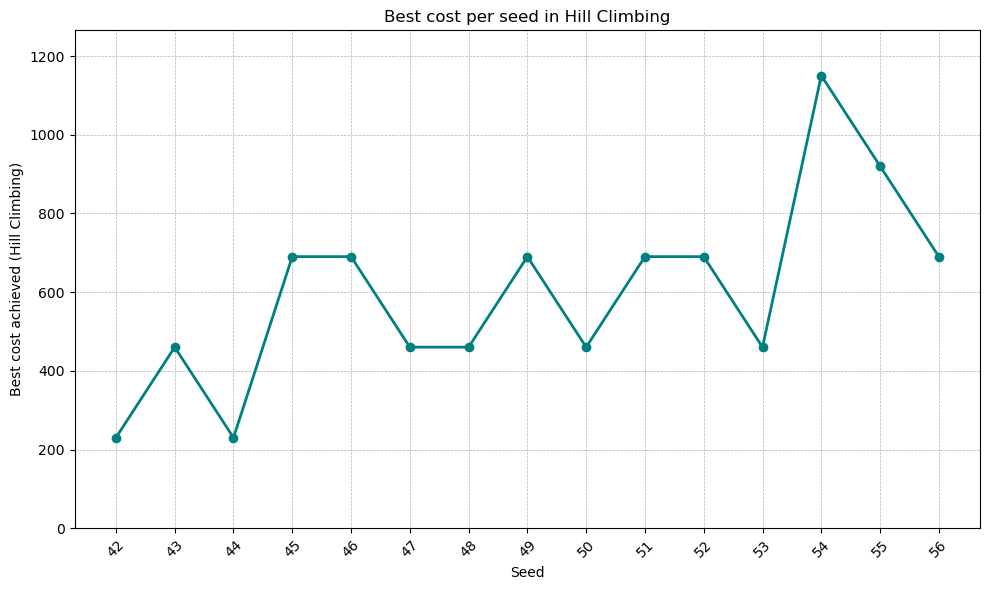

In [13]:
# 5.3 Plot the best cost from each seed as a line chart
best_costs = [cost for (_, cost, _) in results]

plt.figure(figsize=(10, 6))
plt.plot(seeds, best_costs, marker="o", linestyle="-", linewidth=2, color="teal")
plt.xlabel("Seed")
plt.ylabel("Best cost achieved (Hill Climbing)")
plt.title("Best cost per seed in Hill Climbing")
plt.xticks(seeds, rotation=45)
plt.ylim(0, max(best_costs) * 1.1)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


# 4. Genetic Algorithm


## 4.1 Hyperparameters


In [14]:
def genetic_search(
    pop_size=50, num_generations=100, crossover_rate=0.8, mutation_rate=0.1, seed=42
):
    random.seed(seed)

## 4.2 Initial Population and Baseline Cost


In [15]:
# 1. Create the initial population
population = [
    [random.randint(1, num_periods) for _ in courses] for _ in range(pop_size)
]
# Evaluate the initial cost
costs = [calculate_schedule_cost(ind) for ind in population]

best_history = []


NameError: name 'pop_size' is not defined

## 4.3 Evolutionary Loop


In [ ]:
for gen in range(num_generations):
    # Keep the best individual (elitism)
    best_idx = min(range(pop_size), key=lambda i: costs[i])
    best_history.append(costs[best_idx])
    new_population = [population[best_idx][:]]

    # 2. Generate new individuals
    while len(new_population) < pop_size:
        # Selection (tournament)
        def tournament_select():
            competitors = random.sample(range(pop_size), 3)
            return min(competitors, key=lambda i: costs[i])

        parent_1 = population[tournament_select()]
        parent_2 = population[tournament_select()]

        # Crossover
        if random.random() < crossover_rate:
            point = random.randrange(1, len(courses))
            child1 = parent_1[:point] + parent_2[point:]
            child2 = parent_2[:point] + parent_1[point:]
        else:
            child1, child2 = parent_1[:], parent_2[:]

        # Mutation
        def mutate(ind):
            for i in range(len(ind)):
                if random.random() < mutation_rate:
                    ind[i] = random.randint(1, num_periods)
            return ind

        new_population.append(mutate(child1))
        if len(new_population) < pop_size:
            new_population.append(mutate(child2))

    # Update the costs and population
    population = new_population
    costs = [calculate_schedule_cost(ind) for ind in population]

# Final best individual
best_idx = min(range(pop_size), key=lambda i: costs[i])
best_schedule = population[best_idx]
best_cost = costs[best_idx]

return best_schedule, best_cost, best_history


## 4.4 Multi-Seed Evaluation
Evaluating multiple seeds highlights the robustness of the genetic algorithm and helps identify consistently strong schedules.


In [ ]:
# ----------------------------
# 5. Run the GA for 15 different seeds
# ----------------------------
base_seed = 42
num_runs = 15
num_generations = 100

seeds = [base_seed + i for i in range(num_runs)]
results = []  # (seed, best_cost, best_schedule)

for seed in seeds:
    schedule, cost, history = genetic_search(
        pop_size=50,
        num_generations=num_generations,
        crossover_rate=0.8,
        mutation_rate=0.1,
        seed=seed,
    )
    results.append((seed, cost, schedule))

# 5.1 Identify the global best across all seeds
best_seed, best_cost_global, best_schedule_global = min(results, key=lambda x: x[1])

# 5.2 Report the global best result
print(f"Best global cost: {best_cost_global:.6f}  (seed {best_seed})")

# 4. Check and report violations for this best solution
violations = check_violations(best_schedule_global)
print("Constraint violations for this solution (if any):")
if not violations:
    print("  No violations detected. All requirements are satisfied.")
else:
    for violation in violations:
        print("  -", violation)

print("Schedule (course -> period) for the best global cost:")
for course, period in zip(courses, best_schedule_global):
    print(f"  {course}: {period}")


## 4.5 Cost per Seed


In [ ]:
# 5.3 Plot the best cost from each seed as a line chart
best_costs = [cost for (_, cost, _) in results]

plt.figure(figsize=(10, 6))
plt.plot(seeds, best_costs, marker="o", linestyle="-", linewidth=2, color="purple")
plt.xlabel("Seed")
plt.ylabel("Best cost achieved (GA)")
plt.title(f"Best cost per seed in the Genetic Algorithm ({num_generations} generations)")
plt.xticks(seeds, rotation=45)
plt.ylim(0, max(best_costs) * 1.1)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


## 4.6 Hyperparameter Sweep


In [ ]:
# 2. Hyperparameter configurations to explore: pop_size, num_generations, crossover_rate
pop_sizes = [20, 50, 100]
num_gens = [50, 100, 200]
crossover_rates = [0.4, 0.6, 0.8, 0.9]

# Generate up to 20 combinations (first 20 from the Cartesian product)
configs = []
for ps in pop_sizes:
    for ng in num_gens:
        for cr in crossover_rates:
            configs.append((ps, ng, cr))
            if len(configs) == 20:
                break
        if len(configs) == 20:
            break
    if len(configs) == 20:
        break

# 3. Execute the GA for each configuration (fixed seed, e.g., 42)
results = []
for ps, ng, cr in configs:
    schedule, cost, history = genetic_search(
        pop_size=ps,
        num_generations=ng,
        crossover_rate=cr,
        mutation_rate=0.1,
        seed=42,  # same seed for consistent comparison
    )
    results.append(
        {
            "pop_size": ps,
            "num_generations": ng,
            "crossover_rate": cr,
            "best_cost": cost,
            "best_schedule": schedule,
        }
    )

# 4. Identify the global best cost
best_config = min(results, key=lambda r: r["best_cost"])

# 5. Report the global best configuration
print(f"Best global cost: {best_config['best_cost']:.6f}")

# 4. Check and report violations for this best solution
violations = check_violations(best_config["best_schedule"])
print("Constraint violations for this solution (if any):")
if not violations:
    print("  No violations detected. All requirements are satisfied.")
else:
    for violation in violations:
        print("  -", violation)

print()
print("Configuration that achieved this cost:")
print(
    f"  pop_size={best_config['pop_size']}, num_generations={best_config['num_generations']}, crossover_rate={best_config['crossover_rate']}"
)
print("Schedule (course -> period) for this configuration's best solution:")
for course, period in zip(courses, best_config["best_schedule"]):
    print(f"  {course}: {period}")

# 6. Plot the best cost for each configuration
labels = [
    f"ps={r['pop_size']}, ng={r['num_generations']}, cr={r['crossover_rate']}"
    for r in results
]
best_costs = [r["best_cost"] for r in results]

plt.figure(figsize=(12, 6))
plt.plot(range(len(results)), best_costs, marker="o", linestyle="-")
plt.xticks(range(len(results)), labels, rotation=45, ha="right")
plt.xlabel("Configuration index")
plt.ylabel("Best cost achieved")
plt.title("Best cost per GA configuration")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.ylim(0, max(best_costs) * 1.1)
plt.tight_layout()
plt.show()
